# Quickstart: Estimate Forest Restoration Impacts

This notebook walks through a counterfactual assessment of a forest restoration project. It compares the observed project site with a weighted combination of similar, unrestored locations—a **synthetic control**—to estimate what might have happened without the intervention.

By the end, you will have:

- a map of the project, sampled treatment pixels, and eligible donor pixels;
- annual above-ground biomass (AGB) and vegetation-height (SVH) time series;
- diagnostic tables for the synthetic-control fit; and
- plots comparing observed and counterfactual outcomes after restoration.

The workflow has three main stages:

1. **Choose a project site and intervention year.**
2. **Find comparable control pixels.** Nearby pixels are screened for similar human pressure, disturbance history, and ecological conditions.
3. **Estimate the impact.** Eligible controls are weighted to reproduce the site's pre-intervention trajectory, then compared with the observed post-intervention trajectory.

> **Before you start:** Run this notebook from the repository root using the `.venv` Python kernel created by `uv sync`, and make sure you can access Google Earth Engine. In the setup cell below, replace `EE_PROJECT` with your own Earth Engine-enabled Google Cloud project. The first run may open a browser for authentication.


In [1]:
import json

import ee
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display
from loguru import logger

from restoration_counterfactuals.datasets import (
    load_agb_imgc,
    load_example,
    load_svh_imgc,
)
from restoration_counterfactuals.matching import (
    donor_search_area,
    matching_layers,
    sample_treatment_pixels,
    scale_by_sqrt_area,
    select_donors,
    similarity_masks,
)
from restoration_counterfactuals.plotting import (
    impact_figure_with_donors,
    matching_map,
)
from restoration_counterfactuals.synthetic_control import fit_synthetic_control
from restoration_counterfactuals.timeseries import (
    extract_donor_values,
    extract_project_means,
)

EE_PROJECT = "ee-speckerfelix"

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## 1. Choose a restoration site

A site needs a polygon boundary and an `intervention_year` property. Choose **one** of the options below:

1. **Use an example site (recommended for a first run).** Change the name in the next cell, then run it. Available examples are listed in the code comment.
2. **Use your own GeoJSON.** Draw or upload a polygon at [geojson.io](https://geojson.io/), add an integer `intervention_year` to its properties, paste it into the following cell, and uncomment that cell. If you use this option, do not also run the example-site cell.

The intervention year should be the first year in which restoration activities could affect the measured outcomes. The selected site and year are used throughout the rest of the notebook.


In [2]:
# Option 1: Use one of the four example sites.
site = load_example("bom_futuro")  # bom_futuro, campeche_mexico, finca_rinconada, reforest_now_au
intervention_year = site.getNumber("intervention_year").getInfo()
print(f"Intervention Year: {intervention_year}")

Intervention Year: 2017


In [3]:
# # Option 2: Paste a GeoJSON string containing an intervention year.
# # Draw a polygon at https://geojson.io and copy the resulting GeoJSON.
# # Add "intervention_year": 2022 to the feature's properties.

# site_geojson = """{
#   "type": "FeatureCollection",
#   "features": [
#     {
#       "type": "Feature",
#       "properties": {
#         "intervention_year": 2022
#       },
#       "geometry": {
#         "type": "Polygon",
#         "coordinates": [[
#           [-54.0890, -11.0800],
#           [-54.0870, -11.0800],
#           [-54.0870, -11.0820],
#           [-54.0890, -11.0820],
#           [-54.0890, -11.0800]
#         ]]
#       }
#     }
#   ]
# }"""

# # Accept either a FeatureCollection or a single Feature.
# geojson = json.loads(site_geojson)
# feature = geojson["features"][0] if geojson["type"] == "FeatureCollection" else geojson

# site = ee.Feature(feature)
# intervention_year = site.get('intervention_year').getInfo()

# print(f"Intervention year: {site.get('intervention_year').getInfo()}")

In [4]:
# Assign an identifier for the single-site time-series tables.
site = site.set("site_id", "site")

# Edit control matching parameters in config.yaml
with open("config.yaml") as file:
    settings = yaml.safe_load(file)["CONTROL_MATCHING"]

area_ha = site.geometry().area(10).divide(10_000).getInfo()

logger.debug(f"Site area: {area_ha:.2f} ha")

region = donor_search_area(
    site.geometry(),
    area_ha,
    other_projects=ee.FeatureCollection([]),
    settings=settings,
)

2026-10-06 18:27:06.876 | DEBUG    | __main__:<module>:7 - Site area: 9.22 ha
2026-10-06 18:27:06.878 | DEBUG    | restoration_counterfactuals.matching:donor_search_area:30 - Inclusion buffer: 12660.34863700328 m
2026-10-06 18:27:06.878 | DEBUG    | restoration_counterfactuals.matching:donor_search_area:34 - Exclusion (spillover) buffer: 799.289221662869 m


In [5]:
## Get project area [ha] and define the number of treatment pixels used
layers = matching_layers(intervention_year, region.bounds(10))
n_pixels = int(
    scale_by_sqrt_area(
        area_ha,
        settings["TREATMENT_PIXELS"]["N_MIN"],
        settings["TREATMENT_PIXELS"]["N_MAX"],
    )
)
print(
    {
        "area_ha": area_ha,
        "matching_mode": layers["mode"],
        "requested_treatment_pixels": n_pixels,
    }
)

2026-10-06 18:27:06.891 | DEBUG    | restoration_counterfactuals.datasets:load_lulc:167 - Loading LULC data for year 2016. Closest available year in GLAD dataset is 2015.


{'area_ha': 9.221434835130376, 'matching_mode': 'landcover', 'requested_treatment_pixels': 6}


## 2. Sample the project and find comparable controls

The cells above read the matching settings from `config.yaml`, calculate the project area, define a surrounding donor-search region, and report the matching mode and requested number of treatment samples. The next cells sample locations inside the project and find eligible **donor pixels**—locations used to represent the no-restoration scenario.

Eligibility is checked separately for each sampled treatment pixel. By default, a donor must meet all of these conditions:

- **Location:** It falls within a 10–50 km search buffer, but outside a 0.5–5 km spillover buffer around the project. Buffer sizes scale with project area.
- **Other projects:** It is outside known restoration projects and their 50 m buffers. This quickstart passes an empty exclusion collection, so nearby projects are not excluded unless you provide them.
- **Human pressure:** Its pre-intervention human-modification score differs from the treatment pixel by no more than 0.10.
- **Disturbance history:** Its pre-intervention forest-loss history is compatible with the treatment pixel; when both experienced loss, the recorded loss years must be within one year.
- **Ecological conditions:** For interventions from 2018 onward, AlphaEarth embedding distance must be no more than 0.10. Earlier interventions instead require the same remapped pre-intervention GLAD land-cover class.

The default workflow samples 5–30 treatment pixels on a 20 m sampling grid and keeps up to five donors per treatment pixel. The count scales with project area. Duplicate donor coordinates are removed before model fitting. You can adjust these thresholds in `config.yaml`.


In [6]:
# sample treatment pixels within project site
treatments = sample_treatment_pixels(site, layers, n_pixels, settings["SAMPLE_SCALE"])

# for each treatment pixel, sample donors
donors = select_donors(treatments, region, layers, intervention_year, settings)


In [7]:
treatment_ids = treatments.aggregate_array("treatment_id").distinct().getInfo()

masks_by_treatment = {
    tid: similarity_masks(
        ee.Feature(treatments.filter(ee.Filter.eq("treatment_id", tid)).first()),
        layers,
        intervention_year,
        settings,
    )
    for tid in treatment_ids
}
site_map = matching_map(
    site, region, treatments, donors, masks_by_treatment, exclusions=None
)


In [8]:
site_map

Map(center=[-9.465351179247987, -64.22267620440809], controls=(WidgetControl(options=['position', 'transparent…

### Check the matching map

Use the layer control to inspect the eligibility masks for individual treatment pixels. The displayed donor set combines matches from all treatment samples. Look for reasonable spatial coverage and confirm that donors are outside the project and spillover area. If very few donors remain, revisit the site geometry, intervention year, exclusions, or thresholds in `config.yaml` before continuing.

A donor location that matches more than one treatment pixel is included only once, so repeated coordinates cannot influence the ridge penalty.


## 3. Extract outcome time series

Next, extract annual outcomes for both the project and donor pixels:

- **AGB:** above-ground biomass
- **SVH:** short vegetation height

The project value is summarized across the site, while donor values are retained by location for synthetic-control fitting. The resulting tables remain available as `treated_ts` and `donor_ts` for inspection and further analysis. Confirm that several complete pre-intervention years are available before fitting the model.


In [9]:
treated_tables, donor_tables = [], []
for variable, loader in [("svh", load_svh_imgc), ("agb", load_agb_imgc)]:
    collection, projection = loader()
    treated_tables.append(extract_project_means(site, collection, projection, variable))
    donor_tables.append(extract_donor_values(donors, collection, projection, variable))
treated_ts = pd.concat(treated_tables, ignore_index=True)
donor_ts = pd.concat(donor_tables, ignore_index=True)

## 4. Fit and inspect the synthetic controls

A separate constrained ridge model is fitted for AGB and SVH using complete years strictly before the intervention; at least three pre-intervention years are required. Donor weights are nonnegative and sum to one, making the synthetic control a weighted average of observed donor locations.

The model tests 30 penalty values from 10⁻⁶ to 10³ and selects the strongest regularization whose pre-intervention root mean squared prediction error (RMSPE) is within 2% of the best fit. For each outcome, the cell stores trajectories, donor weights, diagnostics, and the penalty search in `fits[variable]`. It displays an impact plot with donor trajectories and saves it as PNG and PDF in the repository root.

When reviewing the results:

1. Check that the observed and synthetic trajectories align well before the intervention.
2. Inspect whether the fit depends heavily on only one or two donors.
3. Interpret the post-intervention gap as the estimated restoration effect only if the pre-intervention fit and donor pool are credible.

> **Important:** This quickstart does not provide uncertainty intervals or a formal causal-identification test. Treat the estimates as exploratory and pair them with sensitivity checks before drawing strong conclusions.


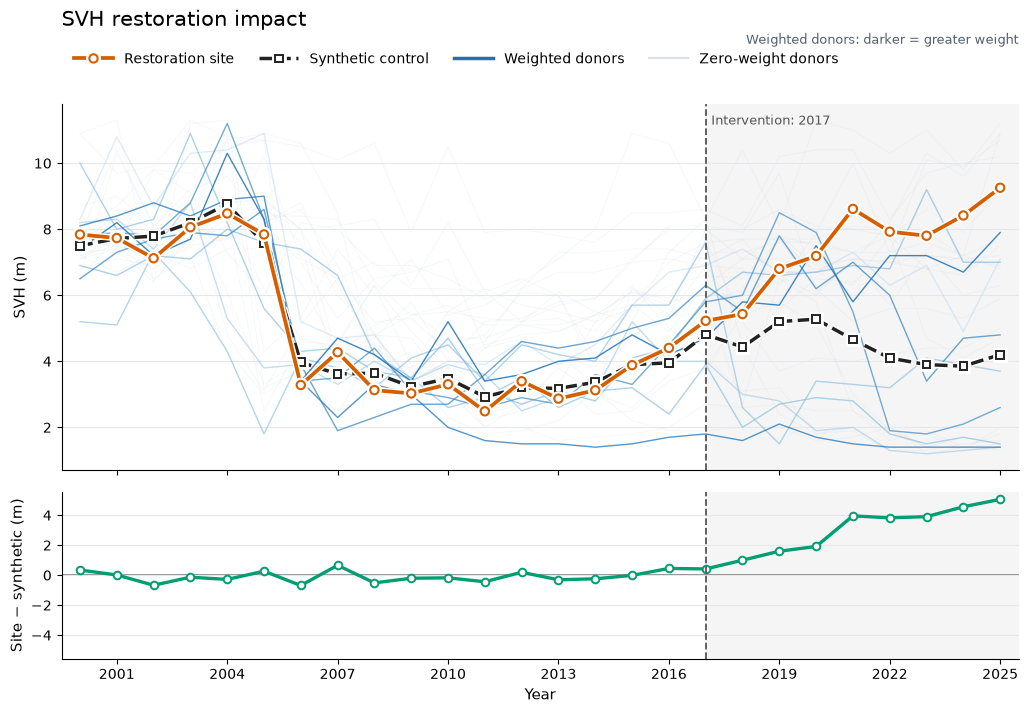

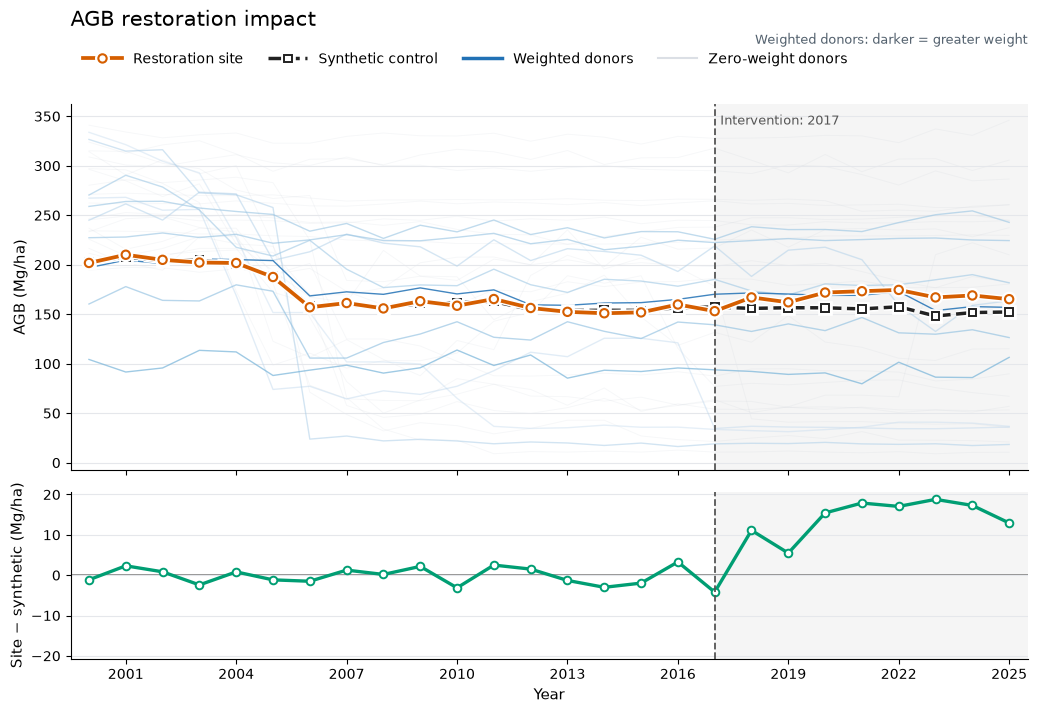

In [10]:
fits = {}
for variable in ("svh", "agb"):
    fit = fit_synthetic_control(
        treated_ts.loc[treated_ts.variable == variable],
        donor_ts.loc[donor_ts.variable == variable],
        intervention_year,
    )
    fits[variable] = fit
    figures = {
        "impacts_w_donor": impact_figure_with_donors(
            fit["trajectories"],
            donor_ts.loc[donor_ts.variable == variable],
            fit["weights"],
            intervention_year,
            variable,
        ),
    }
    for name, fig in figures.items():
        display(fig)
        for extension in ("pdf", "png"):
            fig.savefig(f"{variable}_{name}.{extension}", dpi=180)
        plt.close(fig)